# Lab: Regression Tree

*In this lab, we will build a **Regression Tree** model using scikit-learn, guided by the [Foundational Methodology for Data Science](../../../05_methodology/). While real-world projects require comprehensive documentation at each stage, this lab focuses on a streamlined, practical approach to demonstrate the core concepts and workflow. Therefore we will settle with the summaries of hypothetical stage reports.*

---

> ### 📝 1. Business Understanding Report (Summary)
>
> - **Business Context:** This project addresses a real-estate analytics scenario for a hypothetical company, **"Housewise Analytics"**, operating in the California housing market. California's housing market is characterized by diverse neighborhoods, rapidly changing prices, and growing demand for data-driven decision-making among buyers, sellers, and realtors.
> - **Business Problem:** Stakeholders currently rely on broad averages or intuition, lacking a precise and explainable method to estimate home prices for specific neighborhoods and property characteristics. This uncertainty leads to lost sales opportunities, mispricing, and inefficient market decisions.
> - **Project Goal:** To build a **predictive model** that uses available district-level features (such as location, median income, number of rooms, and more) to accurately estimate median home values in California. The objective is to empower more confident and data-driven pricing decisions that benefit both buyers and sellers.

---

> ### 📝 2. Analytic Approach Report (Summary)
>
> - **Problem Type:** *Supervised Regression* - the goal is to predict a **continuous numerical value** (median house value) from district-level features.
> - **Model Selection:** For this lab, the candidate model is a **Regression Tree (Decision Tree Regressor)**. This approach was chosen because it can naturally handle non-linear relationships and feature interactions, which are common in housing data. (Note: In previous labs, simple and multiple linear regression were already explored.)
> - **Evaluation Metrics:**
>   - **R-squared (R²) and Adjusted R-squared:** To measure how much of the variance in house values the model can explain, while adjusting for the number of features.
>   - **RMSE (Root Mean Squared Error):** To provide a direct and interpretable measure of average prediction errors, using the original units of the target (house value in $100,000s).
>   - **Feature Importance:** To identify which features (e.g., median income, rooms, latitude/longitude) have the largest impact on price predictions.
> - **Motivation for Model Selection:** In a real-world analytic workflow, **Exploratory Data Analysis (EDA)** would precede model building. EDA (including scatterplots and residual analysis) often uncovers non-linear relationships between predictors and housing prices, motivating the use of regression trees. Regression trees can capture threshold, interaction, and piecewise patterns that linear models miss.
>
> ⚠️ **Caution:** For clarity and focus, this lab considers only a regression tree. In real-world projects, it is best practice to compare several modeling approaches (including advanced ensembles and regularized models) to select the most robust solution.

---

> ### 📝 3. Data Requirements Report (Summary)
>
> - **Data Source:** The lab will use the **California Housing dataset** (available via scikit-learn), which includes data aggregated from 20,000+ block groups across California.
> - **Features (Independent Variables):**
>    - **MedInc**: Median income in block group (`med_income`)
>    - **HouseAge**: median house age in block group (`med_age`)
>    - **AveRooms**: average number of rooms per household (`avg_rooms`)
>    - **AveBedrms**: average number of bedrooms per household (`avg_bedrooms`)
>    - **Population**: block group population (`population`)
>    - **AveOccup**: average number of household members (`avg_occup`)
>    - **Latitude**: block group latitude (`lat`)
>    - **Longitude**: block group longitude (`long`)
> - **Target (Dependent Variable):** Median house value for California districts, expressed in hundreds of thousands of dollars ($100,000s). (`med_value`)
> - **Granularity & Privacy:** Each row represents aggregated statistics for a California census block group (district), not individual households. The dataset is fully anonymized and contains no sensitive or personally identifiable information (PII).

---

## Stage 4: Data Collection

In [155]:
# Necessary imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib

from sklearn.datasets import fetch_california_housing

# Configurations
plt.style.use("fivethirtyeight")
sns.set_theme(style="white", palette="colorblind")

### 4.1 Extraction

In [156]:
# Extract data from the source system
try:
    raw_data = fetch_california_housing()
    print(f"Data has been extracted from the source system as '{type(raw_data)}'")
except Exception as e:
    print(f"An error occurred while extracting data: {e}")

Data has been extracted from the source system as '<class 'sklearn.utils._bunch.Bunch'>'


In [157]:
# Create a DataFrame with the original, untouched column names
raw_df = pd.DataFrame(data=raw_data.data, columns=raw_data.feature_names)
raw_df['target'] = raw_data.target

# Define and create the raw data directory
raw_data_dir = Path("../data/raw")
raw_data_dir.mkdir(parents=True, exist_ok=True)

# Define the file path and save the raw DataFrame
raw_data_path = raw_data_dir / "california_housing_raw_v1.csv"
raw_df.to_csv(raw_data_path, index=False)

print(f"Extracted data has {raw_df.shape[0]} samples and {raw_df.shape[1]} features, with {raw_df.isnull().values.sum()} missing values out of {raw_df.size}.")
print(f"Raw, untouched data has been saved to: {raw_data_path}\n")
raw_df.head()

Extracted data has 20640 samples and 9 features, with 0 missing values out of 185760.
Raw, untouched data has been saved to: ../data/raw/california_housing_raw_v1.csv



,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### 4.2. Transformation

In [158]:
# Read the raw data
interim_df = pd.read_csv(raw_data_path)

In [159]:
# Rename columns
interim_df = interim_df.rename(columns={
    'MedInc':'med_income',
    'HouseAge': 'med_age',
    'AveRooms': 'avg_rooms',
    'AveBedrms': 'avg_bedrooms',
    'Population': 'population',
    'AveOccup': 'avg_occup',
    'Latitude': 'lat',
    'Longitude': 'long',
    'target': 'med_value'
})

In [160]:
# Manually check the minimum and maximum values for all numerical columns for any abnormalities
print("\n--- Min/Max Summary of Numerical Data ---")
display(interim_df.describe().loc[['min', 'max']]) 


--- Min/Max Summary of Numerical Data ---


,med_income,med_age,avg_rooms,avg_bedrooms,population,avg_occup,lat,long,med_value
min,0.4999,1.0,0.846154,0.333333,3.0,0.692308,32.54,-124.35,0.14999
max,15.0001,52.0,141.909091,34.066667,35682.0,1243.333333,41.95,-114.31,5.00001


* 📌 There seems to be unusually high values in average rooms, average bedrooms, population, and average occupancy. However, at this stage we can not be 100% sure that these are data entry errors, as they may represent legitimate cases such as hotels, group living environments, or unique properties.

### 4.3. Loading

In [161]:
# Define and create the interim data directory
interim_data_dir = Path("../data/interim")
interim_data_dir.mkdir(parents=True, exist_ok=True)

# Define the interim file path and save the transformed DataFrame
interim_data_path = interim_data_dir / "california_housing_interim_v1.parquet"
interim_df.to_parquet(interim_data_path, index=False)

### 4.4. Verification

In [162]:
# Load the final interim data and verify its contents
try:
    df_verified = pd.read_parquet(interim_data_path)
    print(f"Verification successful. The following DataFrame is ready for analysis with {df_verified.shape[0]} samples and {df_verified.shape[1]} features:")
    display(df_verified.sample(5))
except Exception as e:
    print(f"An error occurred while verifying the interim data: {e}")

Verification successful. The following DataFrame is ready for analysis with 20640 samples and 9 features:


,med_income,med_age,avg_rooms,avg_bedrooms,population,avg_occup,lat,long,med_value
3119,4.1518,13.0,6.198068,1.084541,1181.0,2.852657,35.73,-117.87,0.918
12699,2.6442,34.0,3.127273,0.690909,149.0,2.709091,38.61,-121.44,0.550
14976,4.3714,23.0,6.202673,1.042316,1456.0,3.242762,32.70,-117.00,1.310
9633,3.0909,30.0,5.503171,1.071882,1491.0,3.152220,37.18,-121.06,1.234
15102,3.1979,20.0,5.186677,1.027111,3687.0,2.855926,32.83,-116.99,1.546



---

> ### 📝 4. Data Collection Report (Summary)
> 
> - **Extraction:** The California Housing dataset was retrieved from scikit-learn's repository and saved in its original, untouched form as a raw `.csv` file for reproducibility and provenance.
> - **Transformation:**
>   - All columns were renamed as specified in the Data Requirements Report (Summary).
>   - Data quality checks revealed unusually high values in average rooms (`avg_rooms`), average bedrooms (`avg_bedrooms`), population (`population`), and average occupancy (`avg_occup`). These potential outliers were **not** automatically removed during transformation, as they may represent legitimate cases such as hotels, group living environments, or unique properties. Determining their treatment is left for the data scientist at the EDA stage, based on domain knowledge and analytic objectives.
> - **Loading:** The standardized dataset was saved as a `.parquet` file in the `/data/interim` directory, providing an analysis-ready starting point for all subsequent work.
> - **Verification:** The interim DataFrame contains 20,640 rows and 9 columns, with all variable names in snake_case and no missing values detected.

---

## Stage 5: Data Understanding

### 5.1. Preparation for Exploratory Data Analysis (EDA)

In [163]:
# Create a new DataFrame for the EDA, with the useful columns
df_eda = df_verified.copy() # We need ALL columns

# Final check for the column names, data types, null values, and memory usage
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   med_income    20640 non-null  float64
 1   med_age       20640 non-null  float64
 2   avg_rooms     20640 non-null  float64
 3   avg_bedrooms  20640 non-null  float64
 4   population    20640 non-null  float64
 5   avg_occup     20640 non-null  float64
 6   lat           20640 non-null  float64
 7   long          20640 non-null  float64
 8   med_value     20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [164]:
# Sample 5 rows from the DataFrame to verify that the DataFrame is ready for EDA
df_eda.sample(5)

,med_income,med_age,avg_rooms,avg_bedrooms,population,avg_occup,lat,long,med_value
763,2.1382,37.0,4.569794,0.997712,1349.0,3.086957,37.66,-122.08,1.666
11630,5.6093,17.0,5.970968,1.116129,770.0,2.483871,33.82,-118.03,2.444
10659,6.3767,24.0,6.379870,1.073052,1831.0,2.972403,33.67,-117.81,2.690
8709,5.0000,34.0,6.124567,1.006920,916.0,3.169550,33.85,-118.35,3.542
8693,6.3992,36.0,5.693333,1.066667,473.0,3.153333,33.86,-118.33,2.596


In [165]:
# Create useful data structures for EDA
numeric_cols = df_eda.columns.to_list()
numeric_features = numeric_cols[:-1]
cols_dict = {
    'med_income': 'Median Income',
    'med_age': 'Median House Age',
    'avg_rooms': 'Average Number of Rooms per Household',
    'avg_bedrooms': 'Average Number of Bedrooms per Household',
    'population': 'Population',
    'avg_occup': 'Average Number of Household Members',
    'lat': 'Latitude',
    'long': 'Longitude',
    'med_value': 'Median House Value (in $100,000s)'
}

### 5.2. Descriptive Statistics

In [166]:
# Generate the descriptive statistics for the numerical variables
stats_df = df_eda.describe().T

# Calculate and add the Coefficient of Variation (CV) column
stats_df['cv'] = stats_df['std'] / stats_df['mean']

# Display the result
stats_df

,count,mean,std,min,25%,50%,75%,max,cv
med_income,20640.0,3.870671,1.899822,0.499900,2.563400,3.534800,4.743250,15.000100,0.490825
med_age,20640.0,28.639486,12.585558,1.000000,18.000000,29.000000,37.000000,52.000000,0.439448
avg_rooms,20640.0,5.429000,2.474173,0.846154,4.440716,5.229129,6.052381,141.909091,0.455733
avg_bedrooms,20640.0,1.096675,0.473911,0.333333,1.006079,1.048780,1.099526,34.066667,0.432134
population,20640.0,1425.476744,1132.462122,3.000000,787.000000,1166.000000,1725.000000,35682.000000,0.794444
avg_occup,20640.0,3.070655,10.386050,0.692308,2.429741,2.818116,3.282261,1243.333333,3.382356
lat,20640.0,35.631861,2.135952,32.540000,33.930000,34.260000,37.710000,41.950000,0.059945
long,20640.0,-119.569704,2.003532,-124.350000,-121.800000,-118.490000,-118.010000,-114.310000,-0.016756
med_value,20640.0,2.068558,1.153956,0.149990,1.196000,1.797000,2.647250,5.000010,0.557855


* 📌 **`med_income`** has a wide spread (CV ≈ 0.49) with values ranging from ~$0.5$k to $15$k, indicating significant economic diversity among California districts. This variable is likely to be an important predictor for housing value splits.
* 📌 **`population`** shows high variability (CV ≈ 0.79) and extreme maximum values (over 35,000), which may signal the presence of large or aggregated block groups—regression trees can naturally handle such heterogeneity without requiring transformation.
* 📌 **`avg_rooms`** and **avg_bedrooms** both have moderate variability (CV ≈ 0.46 and 0.43) but their maximum values (142 and 34, respectively) are much higher than the 75th percentile, suggesting clusters of very large buildings (e.g., apartments, hotels)—tree-based splits are well-suited to capture such discontinuities.
* 📌 **`avg_occup`** (average occupancy) is extremely skewed (CV ≈ 3.38, max ≈ 1243), reflecting that a small number of districts have dramatically higher values; such outliers won’t destabilize regression trees, making this model robust to including the full data range.
* 📌 **`med_value`** (target) also displays high dispersion (CV ≈ 0.56), supporting the value of flexible, non-linear approaches like regression trees to model price variability.
* 📌 Both **`lat`** and **`long`** have low CV and broad ranges, confirming the data captures geographic diversity across California, which regression trees can exploit when identifying location-based value thresholds.

### 5.3. Univariate Analysis
To understand the distribution and variability of each variable, we plot histograms and boxplots. This helps spot skewness, outliers, modality, and informs transformations or splitting for regression trees. The target variable `med_value` is given particular attention.

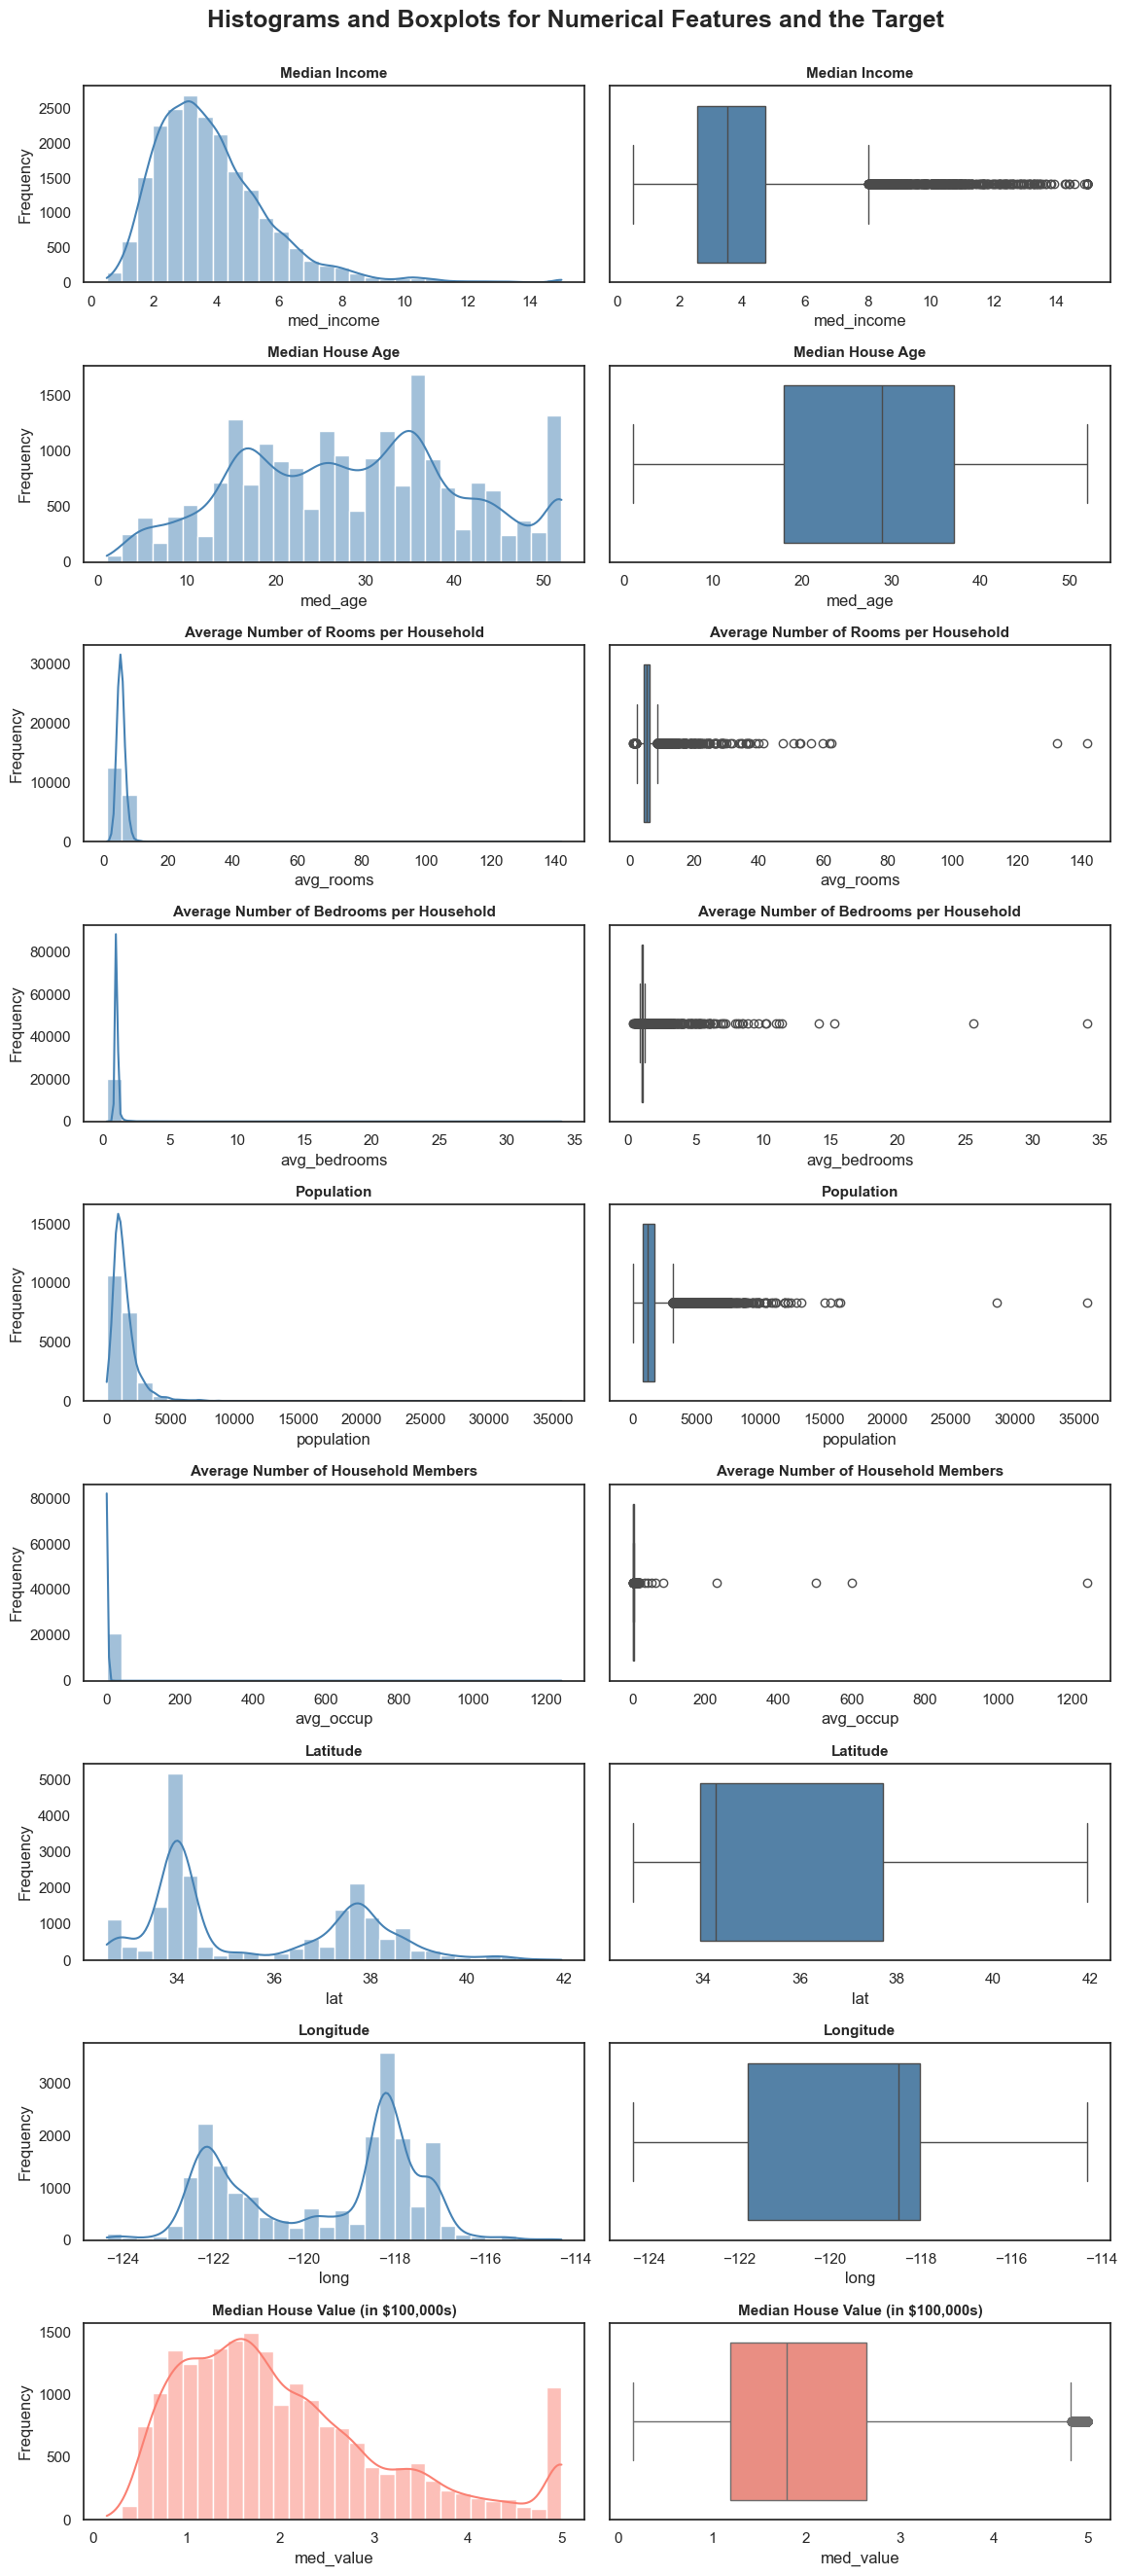

In [ ]:
n = len(numeric_cols)
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, n * 3))

for i, col in enumerate(numeric_cols):
    color = "salmon" if col == "med_value" else "steelblue"
    
    # Histograms (left column)
    sns.histplot(data=df_eda, x=col, kde=True, bins=30, ax=axes[i, 0], color=color)
    axes[i, 0].set_title(cols_dict[col], fontsize=11, fontweight="bold")
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel("Frequency")
    
    # Boxplots (right column)
    sns.boxplot(data=df_eda, x=col, ax=axes[i, 1], orient="h", color=color)
    axes[i, 1].set_title(cols_dict[col], fontsize=11, fontweight="bold")
    axes[i, 1].set_xlabel(col)

plt.suptitle("Histograms and Boxplots for Numerical Features and the Target", fontsize=18, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.98))
plt.show()